# Week 7: Transfer Learning — BERT & Sentence-BERT

This notebook extends the Transformer architecture from Week 6 into full encoder stacks, then introduces BERT pre-training, fine-tuning, and Sentence-BERT (SBERT) for semantic similarity and retrieval.

## Learning Goals
- Stack multiple `TransformerBlock` layers from `utils.py` to build a complete encoder architecture.
- Understand BERT's bidirectional pre-training objectives: Masked Language Modeling (MLM) and Next Sentence Prediction (NSP).
- Fine-tune a pre-trained BERT model for IMDb sentiment classification using the Hugging Face `Trainer` API.
- Understand why BERT is slow for semantic similarity tasks and how SBERT solves this with a Siamese network.
- Build a semantic similarity pipeline with SBERT embeddings and compare against the Week 3 DAN baseline.

## Reused Assets from Week 6
This week reuses the saved IMDb tokenized assets and the `utils.py` building blocks from previous weeks.

- `../week6-transformer-attention/data/imdb_bpe_dataset.pt` (or the Week 5 path)
- `../week5-CNN-for-text/data/bpe_vocab.json`
- `../week5-CNN-for-text/data/bpe_merges.json`
- `../week5-CNN-for-text/models/vocab_config.json`
- `../week6-transformer-attention/models/tiny_transformer_imdb_rope.pt` (Week 6 checkpoint)

For Day 4 and Day 5, Hugging Face datasets and the `sentence-transformers` library are also required.

## Suggested Multi-Day Flow
- **Day 1:** Stack `TransformerBlock` layers from `utils.py` into a full encoder and probe its representations.
- **Day 2:** Explore BERT's architecture and pre-training objectives (MLM and NSP) without writing them from scratch.
- **Day 3:** Fine-tune a pre-trained BERT model on IMDb using the Hugging Face `Trainer` API.
- **Day 4:** Introduce SBERT and Siamese networks; understand why they are faster for similarity tasks.
- **Day 5:** Build a semantic search pipeline with SBERT embeddings and compare it with the Week 3 DAN baseline.

You can treat each day as one notebook checkpoint instead of trying to finish the full notebook in one sitting.

In [38]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

# Reused directly from utils.py — same as Week 6
from utils import (
    create_bert,
    create_sbert,
    linear_cka,
    bpe_batch_encode,
    evaluate_binary_classifier,
    get_device,
    load_json,
    masked_mean_pool,
    clean_memory,
    TinyTransformerClassifier
)
from transformers import BertTokenizer, BertModel, BertTokenizer, logging, pipeline
# Only show errors, ignore the warnings/info
logging.set_verbosity_error() 


In [2]:
test_ds = torch.load("../week3-embedding/datasets/test_ds.pt", weights_only=False)
test_loader = DataLoader(test_ds, batch_size=32)
batch_input_ids, batch_masks, batch_labels = next(iter(test_loader))
bpe_vocab = load_json("../week3-embedding/datasets/bpe_vocab.json")
bpe_merges = load_json("../week3-embedding/datasets/bpe_merges.json")
vocab_config = load_json("../week3-embedding/models/vocab_config.json")

id_to_token = {idx: token for token, idx in bpe_vocab.items()}
vocab_size = vocab_config["vocab_size"]
pad_id = vocab_config["pad_id"]
device = get_device()

embedding_layer = torch.load("../week3-embedding/models/imdb_embedding_layer.pt", map_location=device, weights_only=True)
embedding_weight = embedding_layer["weight"].to(device)
embedding_dim = embedding_weight.size(1)
embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_id)


print("device:", device)
print("batch_input_ids shape:", tuple(batch_input_ids.shape))
print("labels shape:", tuple(batch_labels.shape))
print("batch_masks shape:", tuple(batch_masks.shape))
print("vocab size:", vocab_size)
print("pad id:", pad_id)
print("embedding_weight shape:", tuple(embedding_weight.shape))

device: mps
batch_input_ids shape: (32, 128)
labels shape: (32,)
batch_masks shape: (32, 128)
vocab size: 590
pad id: 589
embedding_weight shape: (590, 384)


## Day 1: Building a Full Transformer Encoder

The goal for Day 1 is to stack the `TransformerBlock` layers from `utils.py` into a full encoder and understand how layer depth changes the representations it builds.

### From Block to Encoder

In Week 6 we built and inspected a single `TransformerBlock`. An encoder is simply a stack of those blocks, one after another. Each block receives the output of the previous one as its new `x`, so representations accumulate context across layers.

The full encoder pipeline (if using absolute position encoding) is:

$$
x_0 = \text{Embedding}(\text{input\_ids}) + \text{PositionalEncoding}
$$
$$
x_l = \text{TransformerBlock}_l(x_{l-1}), \quad l = 1, \ldots, L
$$
$$
h = \text{LayerNorm}(x_L)
$$

The `TinyBERT` class from `utils.py` already does exactly this except it uses rotary position encoding — it is a stacked encoder. Today we look *inside* it: we probe the representation at each layer using CKA (Centered Kernel Alignment) to see how much layers agree with each other.

### Layer Similarity with CKA

A simple way to compare representations at two layers is **linear Centered Kernel Alignment (CKA)**. For two representation matrices $X$ and $Y$ (each of shape `[n_examples, d]`), linear CKA is:

$$
\text{CKA}(X, Y) = \frac{\lVert Y^T X \rVert_F^2}{\lVert X^T X \rVert_F \cdot \lVert Y^T Y \rVert_F}
$$

CKA ranges from 0 (representations are completely different) to 1 (representations are identical up to linear transformation). It is a useful diagnostic for checking whether later encoder layers are actually building on top of earlier ones or just repeating themselves.

A few things to expect:
- Adjacent layers tend to be more similar (higher CKA) than distant ones.
- The very first and last layers often differ the most — early layers encode surface features while later layers encode more abstract patterns.
- Because our encoder here is untrained (we reuse frozen BPE embeddings and random block weights), the CKA pattern will look noisier than in a trained model.

The Frobenius norm is defined as the square root of the sum of the absolute squares of its elements:

$$ |A|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2} $$

It can also be written elegantly in terms of the matrix trace:

$$ |A|_F = \sqrt{\text{Tr}(A^T A)} $$

In [3]:
# Initialize our TinyBERT encoder from scratch
num_layers = 4
num_heads = 4

tiny_bert = create_bert(
    vocab_size=vocab_size,
    d_model=embedding_dim,
    num_heads=num_heads,
    mlp_hidden_dim=4 * embedding_dim,
    num_layers=num_layers,
    pad_id=pad_id,
    use_rope=True,
    use_absolute_positions=False,
    pretrained_embedding_weight=embedding_weight.detach().cpu()
).to(device)


print(f"TinyBERT Parameters: {sum(p.numel() for p in tiny_bert.parameters())}")
print(tiny_bert)

TinyBERT Parameters: 7325184
TinyBERT(
  (embedding): Embedding(590, 384, padding_idx=589)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (self_attn_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (self_attn): MultiHeadAttention(
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (k_proj): Linear(in_features=384, out_features=384, bias=True)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
      )
      (ffn_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True, bias=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=1536, out_features=384, bias=True)
          (4): Dropout(p=0.1

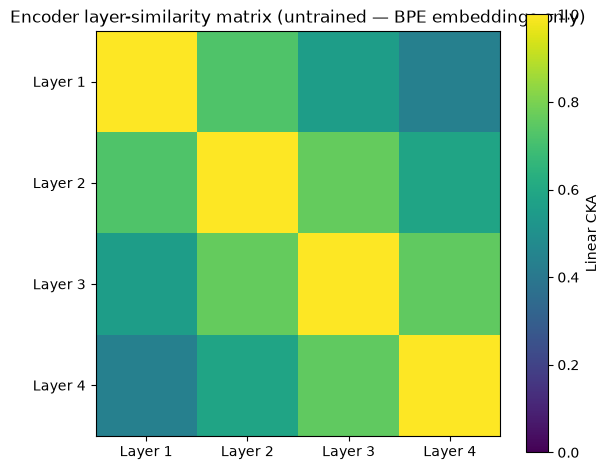

CKA matrix (row i, col j = similarity between layer i and layer j):
tensor([[1.0000, 0.7250, 0.5570, 0.4340],
        [0.7250, 1.0000, 0.7650, 0.5830],
        [0.5570, 0.7650, 1.0000, 0.7540],
        [0.4340, 0.5830, 0.7540, 1.0000]])


In [4]:
tiny_bert.eval()

probe_size = 128
probe_ids = batch_input_ids[:probe_size, :].to(device)
probe_masks = batch_masks[:probe_size, :].to(device)

# Collect layer representations manually
layer_reps = []
with torch.no_grad():
    x = tiny_bert.embedding(probe_ids)
    x = tiny_bert.dropout(x)
    for block in tiny_bert.blocks:
        x = block(x=x, attention_mask=probe_masks)
        pooled = masked_mean_pool(x, probe_masks)  # [n, d]
        layer_reps.append(pooled.detach().cpu())

# Compute pairwise CKA
n_layers = len(layer_reps)
cka_matrix = torch.zeros(n_layers, n_layers)
for i in range(n_layers):
    for j in range(n_layers):
        cka_matrix[i, j] = linear_cka(layer_reps[i], layer_reps[j])

plt.figure(figsize=(6, 5))
plt.imshow(cka_matrix.numpy(), vmin=0, vmax=1, cmap="viridis")
plt.colorbar(label="Linear CKA")
plt.xticks(range(n_layers), [f"Layer {i+1}" for i in range(n_layers)])
plt.yticks(range(n_layers), [f"Layer {i+1}" for i in range(n_layers)])
plt.title("Encoder layer-similarity matrix (untrained — BPE embeddings only)")
plt.tight_layout()
plt.show()

print("CKA matrix (row i, col j = similarity between layer i and layer j):")
print(cka_matrix.round(decimals=3))

### What the CKA Matrix Tells Us

Even in an untrained encoder the diagonal is always 1 (a layer is perfectly similar to itself). Off-diagonal values show whether layers are building genuinely different representations or largely redundant ones. In a well-trained deep encoder you typically see a staircase pattern where nearby layers are very similar and distant layers diverge, which indicates the encoder is progressively refining its representations rather than repeating the same computation.

## Day 2: BERT Architecture and Pre-Training

The goal for Day 2 is to understand BERT's architecture and the two pre-training objectives that give it strong general-purpose representations, before we fine-tune it on a specific task.

### What BERT Is

BERT (Bidirectional Encoder Representations from Transformers) is a stacked Transformer encoder pre-trained on a large corpus with two self-supervised objectives. Its main architectural properties:

- **Bidirectional self-attention:** unlike a decoder, every token can attend to every other token in both directions. This is the same attention mechanism in `utils.py`'s `MultiHeadAttention` with `is_causal=False`.
- **Special tokens:** `[CLS]` at the start of every sequence accumulates a sequence-level representation; `[SEP]` separates two segments in a paired input.
- **Token type embeddings:** an extra learned embedding (0 or 1) marks which segment each token belongs to — used for NSP.
- **Absolute positional embeddings:** BERT uses *learned* (not sinusoidal) absolute position embeddings added once after the token embedding. This is the same design as the `use_absolute_positions=True` path in `TinyTransformerClassifier`, except BERT learns its position table rather than using the fixed sinusoidal formula.

BERT-base has 12 layers, 12 heads, `d_model=768`, and roughly 110M parameters. BERT-large has 24 layers, 16 heads, `d_model=1024`, and ~340M parameters.

### Masked Language Modeling (MLM)

MLM is BERT's main pre-training objective. During pre-training, 15% of input tokens are selected at random. Of those:
- 80% are replaced with a `[MASK]` token.
- 10% are replaced with a random vocabulary token.
- 10% are left unchanged.

The model must predict the original token at every masked position using the surrounding (both left and right) context:

$$
\mathcal{L}_{\text{MLM}} = -\sum_{i \in \mathcal{M}} \log P(x_i \mid \tilde{x})
$$

where $\mathcal{M}$ is the set of masked positions and $\tilde{x}$ is the corrupted sequence. This forces every encoder layer to build rich bidirectional contextual representations because no causal mask restricts which tokens can see which others.

This is very different from the GPT-style causal language model objective where each token can only attend to past tokens. MLM gives BERT access to full context at the cost of not being autoregressive — so BERT is an encoder, not a generator.

### Next Sentence Prediction (NSP)

NSP is BERT's secondary pre-training objective. The model receives a pair of segments separated by `[SEP]` and must predict whether the second segment actually followed the first in the original corpus (positive pair) or is a random segment (negative pair):

$$
\mathcal{L}_{\text{NSP}} = -\log P(\text{IsNext} \mid h_{[\text{CLS}]})
$$

The classification is made from the `[CLS]` token's hidden state. NSP was designed to teach cross-sentence reasoning, though later work (RoBERTa, ALBERT) found that removing NSP often helps rather than hurts downstream task performance. The intuition is that MLM already provides a strong enough signal; NSP can add noise because the randomly sampled negative pairs are trivially easy to identify from topic mismatch alone.

Despite that criticism, understanding NSP is important because it explains two BERT design choices that you will see throughout the Hugging Face API: the `[CLS]` token at position 0 and the `token_type_ids` input.

### BERT Pre-training Is Not Run Here

Pre-training BERT requires hundreds of gigabytes of text and thousands of GPU hours. We do not reproduce it. Instead, we use Hugging Face's `transformers` library to load a checkpoint that has already been pre-trained, then inspect its structure below.

The important takeaway from Day 2 is the *shape* of the pre-training objectives:
- MLM teaches the model to predict masked tokens from bidirectional context → general token-level representations.
- NSP teaches the model whether two segments are adjacent → a sequence-level representation in `[CLS]`.

Fine-tuning (Day 3) replaces the pre-training heads with a task head and continues training on labeled data.

In [5]:
# Day 2: Inspect a pre-trained BERT checkpoint
# This cell loads the model architecture and prints the layer names so we can see the
# correspondence between BERT's components and what we built in Week 6.

bert_name = "bert-base-uncased"
bert_tokenizer = BertTokenizer.from_pretrained(bert_name)
bert_model = BertModel.from_pretrained(bert_name, output_hidden_states=True).to(device)

print("=== BERT-base architecture summary ===")
total_params = sum(p.numel() for p in bert_model.parameters())
print(f"Total parameters: {total_params:,} ({total_params / 1e6:.1f}M)")
print(f"Number of encoder layers: {bert_model.config.num_hidden_layers}")
print(f"Number of attention heads: {bert_model.config.num_attention_heads}")
print(f"Hidden size (embedding_dim): {bert_model.config.hidden_size}")
print(f"Intermediate FFN size: {bert_model.config.intermediate_size}")
print(f"Vocab size: {bert_model.config.vocab_size}")
print(f"Max position embeddings: {bert_model.config.max_position_embeddings}")
print()
print("TinyBert for comparison:")
print(f"  embedding_dim: {embedding_dim}, num_layers: 4, num_heads: 4")
tiny_params = sum(p.numel() for p in tiny_bert.parameters())
print(f"  Total parameters: {tiny_params:,} ({tiny_params / 1e6:.2f}M)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

=== BERT-base architecture summary ===
Total parameters: 109,482,240 (109.5M)
Number of encoder layers: 12
Number of attention heads: 12
Hidden size (embedding_dim): 768
Intermediate FFN size: 3072
Vocab size: 30522
Max position embeddings: 512

TinyBert for comparison:
  embedding_dim: 384, num_layers: 4, num_heads: 4
  Total parameters: 7,325,184 (7.33M)


In [6]:
# Day 2: Visualize MLM by masking tokens and asking BERT to fill them in
# This is the closest we can get to watching the pre-training objective in action
# without actually training.



fill_mask = pipeline("fill-mask", model=bert_name, device=device)

probe_sentences = [
    "The film was absolutely [MASK], I could not stop watching.",
    "The acting was [MASK] but the plot was predictable and dull.",
    "I would [MASK] this movie to anyone who enjoys slow-burn thrillers.",
]

print("=== BERT MLM predictions (top-3 per mask) ===")
for sentence in probe_sentences:
    results = fill_mask(sentence)
    print(f"\nSentence: {sentence}")
    for result in results[:3]:
        print(f"  [{result['score']:.3f}] {result['token_str']:15s} → {result['sequence']}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

=== BERT MLM predictions (top-3 per mask) ===

Sentence: The film was absolutely [MASK], I could not stop watching.
  [0.191] beautiful       → the film was absolutely beautiful, i could not stop watching.
  [0.110] incredible      → the film was absolutely incredible, i could not stop watching.
  [0.095] stunning        → the film was absolutely stunning, i could not stop watching.

Sentence: The acting was [MASK] but the plot was predictable and dull.
  [0.594] good            → the acting was good but the plot was predictable and dull.
  [0.096] excellent       → the acting was excellent but the plot was predictable and dull.
  [0.063] fine            → the acting was fine but the plot was predictable and dull.

Sentence: I would [MASK] this movie to anyone who enjoys slow-burn thrillers.
  [0.926] recommend       → i would recommend this movie to anyone who enjoys slow - burn thrillers.
  [0.011] give            → i would give this movie to anyone who enjoys slow - burn thrillers.


In [14]:
# Day 2: Compare token representations from early vs late BERT layers
# This is the BERT-scale version of the CKA probe we ran in Day 1.


bert_model.eval()

probe_texts = [
    "The cinematography was breathtaking and the performances were superb.",
    "A tedious and poorly written film that wasted two hours of my life.",
    "Somewhere between brilliant and baffling, this film defies easy categorisation.",
]

encoded = bert_tokenizer(probe_texts, return_tensors="pt", padding=True, truncation=True).to(device)

with torch.no_grad():
    outputs = bert_model(**encoded)

# hidden_states: tuple of (num_layers + 1) tensors, each [batch, seq, 768]
# Index 0 is the embedding layer output; indices 1..12 are the 12 encoder layers.
hidden_states = outputs.hidden_states
print(f"Number of hidden state tensors (embedding + {bert_model.config.num_hidden_layers} layers):",
      len(hidden_states))
print(f"Shape of each hidden state tensor: {tuple(hidden_states[0].shape)}")

# Compare [CLS] token representations across layers using cosine similarity
cls_vectors = torch.stack([h[:, 0, :] for h in hidden_states], dim=0)  # [13, 3, 768]
print("\n[CLS] token cosine similarity between layer 1 and layer 12 per example:")
for i, text in enumerate(probe_texts):
    v_early = cls_vectors[1, i]
    v_late = cls_vectors[12, i]
    cosine_sim = torch.nn.functional.cosine_similarity(v_early.unsqueeze(0), v_late.unsqueeze(0)).item()
    print(f"For text: {text[:60]}...")
    print(f" cosine similarity [{cosine_sim:.3f}]")


Number of hidden state tensors (embedding + 12 layers): 13
Shape of each hidden state tensor: (3, 20, 768)

[CLS] token cosine similarity between layer 1 and layer 12 per example:
For text: The cinematography was breathtaking and the performances wer...
 cosine similarity [0.204]
For text: A tedious and poorly written film that wasted two hours of m...
 cosine similarity [0.163]
For text: Somewhere between brilliant and baffling, this film defies e...
 cosine similarity [0.199]


### Key Takeaways from Day 2

The architecture inside `BertModel` maps directly onto what we built in Week 6:
- `BertEmbeddings` = token embedding + positional embedding + token type embedding.
- Each `BertLayer` = a `TransformerBlock` from `utils.py` with `is_causal=False` and no RoPE (BERT uses learned absolute positions).
- The `[CLS]` hidden state at layer 12 is what BERT fine-tuning uses for classification — this is the sequence-level representation that NSP was designed to enrich.

A low cosine similarity between early and late `[CLS]` vectors tells us the encoder is doing real work: the representation at layer 12 looks quite different from the raw embedding output.

---
## Day 3: Fine-Tuning BERT on IMDb

The goal for Day 3 is to fine-tune a pre-trained BERT model on IMDb sentiment classification and compare its performance against the Week 6 `TinyTransformerClassifier`.

### Fine-Tuning vs Pre-Training

Pre-training learns general representations from large unlabeled corpora. Fine-tuning starts from those weights and continues gradient updates on a small labeled task dataset. Because the pre-trained weights already encode rich language knowledge, fine-tuning typically:
- converges in far fewer steps than training from scratch.
- requires much less labeled data to reach strong performance.
- works well even with only a few thousand labeled examples.

For classification, the standard BERT fine-tuning setup:
1. Prepend `[CLS]` to the input.
2. Pass through all 12 BERT layers.
3. Take the final hidden state of `[CLS]` (shape `[batch, 768]`).
4. Feed it through a small linear classification head.

The cross-entropy loss on labeled examples flows gradients through the classification head and back into all BERT layers. In practice, a low learning rate (typically `2e-5` to `5e-5`) is used so fine-tuning adjusts the pre-trained representations gently rather than overwriting them.

### Hugging Face Trainer API

The `Trainer` class wraps the standard training loop (forward pass, loss, backward, optimizer step, evaluation) and adds gradient accumulation, mixed precision, logging, and checkpointing. We use it here because the focus of Day 3 is the fine-tuning concept rather than the loop mechanics — you already built those from scratch in Weeks 3–6.

In [15]:
# Day 3: Load IMDb via Hugging Face datasets and tokenize with BERT tokenizer

from datasets import load_dataset

seed = 204
max_length = bert_tokenizer.model_max_length

# Use a small subset so this runs in a reasonable time
raw_datasets = load_dataset("imdb")
small_train = raw_datasets["train"].shuffle(seed=seed).select(range(5000))
small_val   = raw_datasets["test"].shuffle(seed=seed).select(range(1000))

def tokenize_fn(batch):
    return bert_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length,
    )

tokenized_train = small_train.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized_val   = small_val.map(tokenize_fn, batched=True, remove_columns=["text"])

tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_val   = tokenized_val.rename_column("label", "labels")
tokenized_train.set_format("torch")
tokenized_val.set_format("torch")

print("Train size:", len(tokenized_train))
print("Val size:",   len(tokenized_val))
print("Sample keys:", tokenized_train.column_names)
print("Sample input_ids shape:", tokenized_train[0]["input_ids"].shape)

Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /Users/mindy/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Sun Jul 19 17:27:52 2026).


Train size: 5000
Val size: 1000
Sample keys: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Sample input_ids shape: torch.Size([512])


In [39]:
# Day 3: Define the fine-tuning model, metrics, and Trainer

import numpy as np
from transformers import (
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
)
import evaluate

bert_ft = BertForSequenceClassification.from_pretrained(
    bert_name,
    num_labels=2,
)

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

training_args = TrainingArguments(
    output_dir="./models/bert_imdb_ft",
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=250,
    seed=seed,
    fp16=torch.cuda.is_available(),  # use mixed precision if GPU is available
    report_to="none",
    disable_tqdm=False,
    log_level="warning"
)

trainer = Trainer(
    model=bert_ft,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

print("Fine-tunable parameters:", sum(p.numel() for p in bert_ft.parameters() if p.requires_grad) / 1e6, "M")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Fine-tunable parameters: 109.483778 M


In [ ]:
clean_memory()

trainer.train()

Memory cleaned.


/Users/mindy/Documents/Learning/GenAI/LLM-transformers/AI-maths-foundations/NLP-learning-notebooks/week7-BERT/week7-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.364971,0.478399,0.900000
2,0.218422,0.439052,0.918000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/mindy/Documents/Learning/GenAI/LLM-transformers/AI-maths-foundations/NLP-learning-notebooks/week7-BERT/week7-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/mindy/Documents/Learning/GenAI/LLM-transformers/AI-maths-foundations/NLP-learning-notebooks/week7-BERT/week7-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [19]:
# Day 3: Run fine-tuning — takes ~10-20 min on CPU, ~2-5 min on GPU
# Reduce num_train_epochs or the subset size above if you want it faster.

# If you already trained and saved checkpoints, load a specific checkpoint
# and skip re-training.
checkpoint_path = "./models/bert_imdb_ft/checkpoint-6250"
bert_ft_ckpt = BertForSequenceClassification.from_pretrained(checkpoint_path)

print(f"Loaded checkpoint weights from: {checkpoint_path}")
# Re-create the Trainer so it uses the loaded weights.
trainer = Trainer(
    model=bert_ft_ckpt,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
)

# trainer.train()
eval_results = trainer.evaluate()
print("\n=== Fine-tuned BERT evaluation on IMDb (4k train / 1k eval) ===")
for k, v in eval_results.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded checkpoint weights from: ./models/bert_imdb_ft/checkpoint-3000


/Users/mindy/Documents/Learning/GenAI/LLM-transformers/AI-maths-foundations/NLP-learning-notebooks/week7-BERT/week7-env/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy
No log,0.504407,0,0.916000



=== Fine-tuned BERT evaluation on IMDb (4k train / 1k eval) ===
  eval_loss: 0.5044
  eval_accuracy: 0.9160


In [26]:
# Day 3: Compare BERT fine-tuning against Week 6 TinyTransformerClassifier
# We load the saved Week 6 RoPE model and evaluate it on the same 1k IMDb val subset
# for a direct apples-to-apples accuracy comparison.

week6_model = TinyTransformerClassifier(
    vocab_size=vocab_size,
    d_model=embedding_dim,
    num_heads=4,
    mlp_hidden_dim=4 * embedding_dim,
    num_layers=4,
    pad_id=pad_id,
    dropout=0.0,
    use_rope=True,
    pretrained_embedding_weight=embedding_weight.detach().cpu(),
).to(device)

week6_model.load_state_dict(torch.load("../week6-transformer/models/tiny_transformer_imdb_rope.pt", 
                                       map_location=device, weights_only=True))
_, w6_acc = evaluate_binary_classifier(
    model=week6_model,
    data_loader=test_loader,
    criterion=nn.BCEWithLogitsLoss(),
    device=device,
)

print(f"Week 6 TinyTransformer (RoPE) val accuracy:   {w6_acc:.4f}")
bert_acc = globals().get("eval_results", {}).get("eval_accuracy", None)
if bert_acc is not None:
    print(f"BERT-base fine-tuned val accuracy:            {bert_acc:.4f}")
    print()
    print("Observations:")
    print("  - BERT benefits from 110M parameters pretrained on ~3.3B words.")
    print("  - Week 6 model was trained from scratch on the same IMDb subset only.")
    print(f"Week 6 TinyTransformer (RoPE) total params: {sum(p.numel() for p in week6_model.parameters())}")
    print("  - The gap between the two is the practical value of transfer learning.")

Week 6 TinyTransformer (RoPE) val accuracy:   0.7282
BERT-base fine-tuned val accuracy:            0.9160

Observations:
  - BERT benefits from 110M parameters pretrained on ~3.3B words.
  - Week 6 model was trained from scratch on the same IMDb subset only.
Week 6 TinyTransformer (RoPE) total params: 7325569
  - The gap between the two is the practical value of transfer learning.


### Fine-Tuning Observations

BERT's advantage over the Week 6 model has two components:
1. **Scale:** 110M parameters vs ~5M in the tiny model.
2. **Pre-training:** 3.3B words of bidirectional context learning before any labeled data.

The combined effect is that BERT reaches strong accuracy in just 3 epochs on 4k examples — the pre-trained weights already know a lot about language; fine-tuning just steers that knowledge toward the sentiment task.

One limitation: BERT's `[CLS]` representation was pre-trained for NSP (a binary cross-sentence task), not for open-ended semantic similarity. Day 4 explains why this matters and how SBERT fixes it.

## Day 4: Sentence-BERT and Siamese Networks

The goal for Day 4 is to understand why standard BERT is slow for semantic similarity and how SBERT solves this with a Siamese network structure that produces fixed-size sentence embeddings.

### The BERT Similarity Problem

Suppose you want to find which of 10,000 sentences is most similar to a query. With standard BERT, you would need to run a forward pass for every (query, candidate) pair:

$$
\text{score}(q, c_i) = f_{\text{BERT}}([\text{CLS}], q, [\text{SEP}], c_i, [\text{SEP}])
$$

For 10,000 candidates that is 10,000 full BERT forward passes at inference time. For 1M candidates that becomes completely infeasible.

The root cause is that BERT cross-attends between the two sequences inside the forward pass, so representations cannot be pre-computed and cached. You must pass both sequences together every time.

### SBERT: Fixed-Size Sentence Embeddings

SBERT (Sentence-BERT, Reimers & Gurevych 2019) solves this by training a Siamese network that maps each sentence independently to a fixed-size embedding vector:

$$
u = \text{Pool}(\text{BERT}(s_A)), \qquad v = \text{Pool}(\text{BERT}(s_B))
$$

Similarity is then a simple vector operation:

$$
\text{sim}(s_A, s_B) = \cos(u, v) = \frac{u \cdot v}{\lVert u \rVert \lVert v \rVert}
$$

Because each sentence is encoded independently, you can pre-compute all 10,000 candidate embeddings once and then find the nearest neighbor with a single cosine similarity operation at query time.

The pooling step aggregates token-level hidden states into one vector. SBERT typically uses **mean pooling** over all non-padding tokens — exactly the `masked_mean_pool` function in `utils.py`.

### Siamese Network Training

A Siamese network is just two copies of the same model (shared weights) applied to two different inputs. During training on a sentence-pair dataset, both towers process their inputs independently and the loss function compares their output vectors:

- **Classification objective (NLI data):** concatenate `u`, `v`, and `|u - v|`, then classify as entailment / neutral / contradiction.
- **Regression objective (STS data):** minimize MSE between `cos(u, v)` and a human similarity score.
- **Triplet objective:** pull anchor and positive together, push anchor and negative apart.

The shared weights mean both sentences pass through the same BERT+pooling pipeline — the network learns to place semantically similar sentences near each other in embedding space.

### Comparison to the Week 3 DAN Baseline

In Week 3 we trained a Deep Averaging Network (DAN) that also produces sentence embeddings by mean-pooling token vectors. SBERT uses the same pooling idea (`masked_mean_pool` in `utils.py`) but on top of 12 layers of bidirectional Transformer context rather than a single-layer embedding lookup. The contextual representations SBERT pools over are far richer, which is why its embeddings support semantic search tasks that the DAN baseline cannot.

In [27]:
# Day 4: Implement a minimal Siamese BERT encoder using the BERT model and utils.py's masked_mean_pool

siamese_bert = create_sbert(bert_model)
siamese_bert.eval()

# Quick sanity check on sentence pairs
sentence_pairs = [
    ("The film was a masterpiece of modern cinema.",
     "This movie is one of the greatest films ever made."),
    ("The film was a masterpiece of modern cinema.",
     "The food at the restaurant was disappointing and cold."),
    ("I loved the performances, especially the lead actor.",
     "The acting in this film was wonderful, particularly the main character."),
]

bert_tok = BertTokenizer.from_pretrained(bert_name)

print("=== Siamese BERT cosine similarities ===")
for sent_a, sent_b in sentence_pairs:
    enc_a = bert_tok(sent_a, return_tensors="pt", padding=True).to(device)
    enc_b = bert_tok(sent_b, return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        sim = siamese_bert(
            enc_a["input_ids"], enc_a["attention_mask"],
            enc_b["input_ids"], enc_b["attention_mask"],
        ).item()
    print(f"  [{sim:.3f}]  A: {sent_a[:55]}")
    print(f"          B: {sent_b[:55]}")
    print()

=== Siamese BERT cosine similarities ===
  [0.806]  A: The film was a masterpiece of modern cinema.
          B: This movie is one of the greatest films ever made.

  [0.555]  A: The film was a masterpiece of modern cinema.
          B: The food at the restaurant was disappointing and cold.

  [0.779]  A: I loved the performances, especially the lead actor.
          B: The acting in this film was wonderful, particularly the



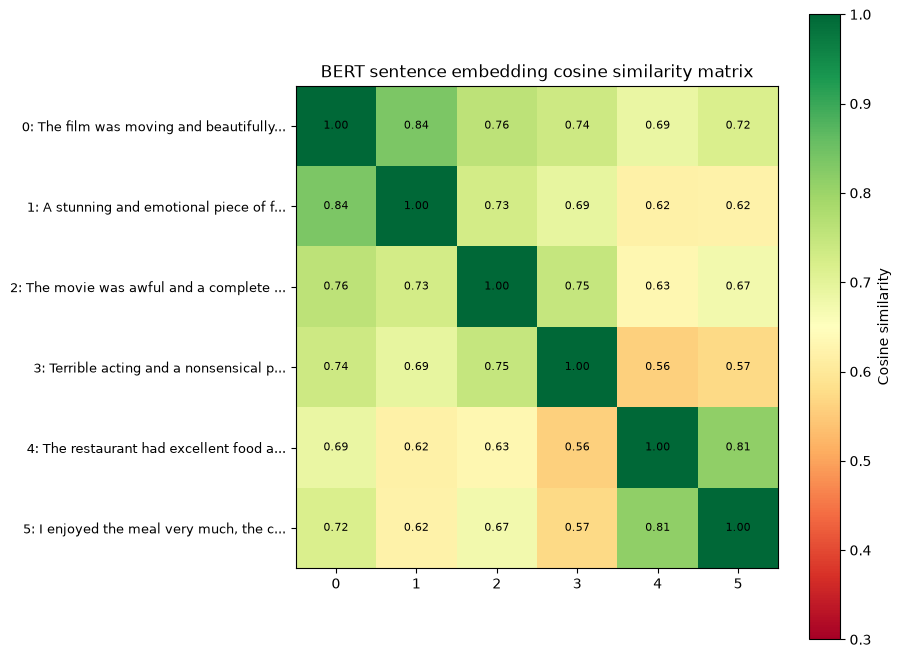

In [28]:
# Day 4: Visualize the embedding space with a tiny similarity matrix
# Shows how sentences cluster by semantic content in BERT embedding space.

sentences_4d = [
    "The film was moving and beautifully shot.",
    "A stunning and emotional piece of filmmaking.",
    "The movie was awful and a complete waste of time.",
    "Terrible acting and a nonsensical plot ruined this film.",
    "The restaurant had excellent food and great service.",
    "I enjoyed the meal very much, the chef was talented.",
]

enc_all = bert_tok(sentences_4d, return_tensors="pt", padding=True, truncation=True).to(device)
with torch.no_grad():
    embs = siamese_bert.encode(enc_all["input_ids"], enc_all["attention_mask"]).cpu()

n = len(sentences_4d)
sim_matrix = torch.zeros(n, n)
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = nn.functional.cosine_similarity(
            embs[i].unsqueeze(0), embs[j].unsqueeze(0)
        ).item()

labels_4d = [f"{i}: {s[:35]}..." for i, s in enumerate(sentences_4d)]

plt.figure(figsize=(9, 7))
im = plt.imshow(sim_matrix.numpy(), cmap="RdYlGn", vmin=0.3, vmax=1.0)
plt.colorbar(im, label="Cosine similarity")
plt.xticks(range(n), [f"{i}" for i in range(n)])
plt.yticks(range(n), labels_4d, fontsize=9)
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{sim_matrix[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("BERT sentence embedding cosine similarity matrix")
plt.tight_layout()
plt.show()

### What the Similarity Matrix Shows

Semantically similar sentences (positive film reviews, negative film reviews, restaurant comments) should cluster with high cosine similarity, while cross-domain pairs should score lower. Even without SBERT fine-tuning on an NLI or STS dataset, mean-pooled BERT already separates these clusters reasonably well.

The `masked_mean_pool` call inside `SiameseBertEncoder.encode` is the exact same function from `utils.py` that the `TinyTransformerClassifier` uses. The key difference is that the token states being pooled come from 12 layers of bidirectional Transformer context rather than a single-layer DAN embedding.

## Day 5: Semantic Search — SBERT vs DAN Baseline

The goal for Day 5 is to build a full semantic search pipeline using the `sentence-transformers` library and compare it against the Week 3 DAN baseline.

### Semantic Search Architecture

A semantic search system has two phases:

1. **Offline (indexing):** encode all candidates into embedding vectors and store them.
2. **Online (retrieval):** encode the query and find nearest neighbors by cosine similarity.

Because SBERT encodes each sentence independently, the indexing step can be precomputed once. Retrieval then costs `O(n · d)` for a brute-force cosine search, or `O(log n)` with an approximate nearest-neighbor index (FAISS, ScaNN, etc.). This is the key practical advantage over cross-encoder BERT.

### DAN Baseline

The Week 3 DAN baseline produces sentence embeddings by mean-pooling learned subword embeddings:
$$
u_{\text{DAN}} = \frac{1}{T} \sum_t e_t
$$
These embeddings are order-agnostic and have no contextual information. We reuse the saved DAN embedding weights from `utils.py` to compute baseline embeddings and compare retrieval quality against SBERT.

In [29]:
# Day 5: Load a fine-tuned SBERT model from sentence-transformers
# 'all-MiniLM-L6-v2' is a fast 6-layer SBERT model fine-tuned on ~1B sentence pairs.

from sentence_transformers import SentenceTransformer

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

# Mini IMDb-style corpus for retrieval demo
corpus = [
    "The director masterfully balances tension and humour throughout the film.",
    "Breathtaking visuals and a haunting score make this an unforgettable experience.",
    "The plot holes are glaring and the pacing is painfully slow.",
    "A deeply moving story about grief, loss, and unexpected friendship.",
    "The lead actor delivers a career-defining performance under difficult circumstances.",
    "Cheap special effects and a lazy script make this a forgettable blockbuster.",
    "The screenplay is sharp, witty, and full of memorable one-liners.",
    "An ambitious but ultimately incoherent sci-fi epic that collapses under its own weight.",
    "Every frame feels deliberately composed; the cinematography is pure artistry.",
    "Despite strong performances, the film struggles to find emotional resonance.",
]

# Encode corpus once (offline indexing step)
corpus_sbert_embs = sbert_model.encode(corpus, convert_to_tensor=True, device=str(device))
print("SBERT corpus embedding shape:", tuple(corpus_sbert_embs.shape))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT corpus embedding shape: (10, 384)


In [32]:
# Day 5: Compute DAN baseline embeddings for the same corpus
# Reuse bpe_batch_encode from utils.py to tokenize, then mean-pool the DAN embedding matrix.
max_seq_len = vocab_config.get("max_seq", batch_input_ids.size(1))
corpus_ids, corpus_masks, _ = bpe_batch_encode(
    texts=corpus,
    bpe_merges=bpe_merges,
    bpe_vocab=bpe_vocab,
    max_len=max_seq_len,
)
corpus_ids = corpus_ids.to(device)
corpus_masks = corpus_masks.to(device)

with torch.no_grad():
    token_embs = embedding_weight[corpus_ids]          # [n, seq_len, d_model]
    corpus_dan_embs = masked_mean_pool(token_embs, corpus_masks)  # [n, d_model]

print("DAN corpus embedding shape:", tuple(corpus_dan_embs.shape))

DAN corpus embedding shape: (10, 384)


In [34]:
# Day 5: Semantic search — SBERT vs DAN baseline side by side

import torch.nn.functional as F

def retrieve_top_k(
    query_emb: torch.Tensor,
    corpus_embs: torch.Tensor,
    corpus_texts: list,
    k: int = 3,
) -> list:
    sims = F.cosine_similarity(query_emb.unsqueeze(0), corpus_embs, dim=-1)
    top_k_idx = sims.topk(k).indices.tolist()
    return [(corpus_texts[i], sims[i].item()) for i in top_k_idx]


queries = [
    "A visually stunning and emotionally powerful film.",
    "Bad movie with terrible writing and poor effects.",
    "Great acting from the main cast.",
]

print("=" * 70)
print("Semantic Search: SBERT (all-MiniLM-L6-v2) vs DAN Baseline")
print("=" * 70)

for query in queries:
    # SBERT query embedding
    q_sbert = sbert_model.encode(query, convert_to_tensor=True, device=str(device))

    # DAN query embedding
    q_ids, q_mask, _ = bpe_batch_encode(
        texts=[query], bpe_merges=bpe_merges, bpe_vocab=bpe_vocab, max_len=max_seq_len
    )
    with torch.no_grad():
        q_tok_embs = embedding_weight[q_ids.to(device)]
        q_dan = masked_mean_pool(q_tok_embs, q_mask.to(device))[0]

    sbert_results = retrieve_top_k(q_sbert, corpus_sbert_embs, corpus)
    dan_results   = retrieve_top_k(q_dan,   corpus_dan_embs,   corpus)

    print(f"\nQuery: '{query}'")
    print("  SBERT top-3:")
    for text, score in sbert_results:
        print(f"    [{score:.3f}] {text}")
    print("  DAN baseline top-3:")
    for text, score in dan_results:
        print(f"    [{score:.3f}] {text}")

Semantic Search: SBERT (all-MiniLM-L6-v2) vs DAN Baseline

Query: 'A visually stunning and emotionally powerful film.'
  SBERT top-3:
    [0.630] Despite strong performances, the film struggles to find emotional resonance.
    [0.574] Breathtaking visuals and a haunting score make this an unforgettable experience.
    [0.505] Every frame feels deliberately composed; the cinematography is pure artistry.
  DAN baseline top-3:
    [0.244] Breathtaking visuals and a haunting score make this an unforgettable experience.
    [0.169] Cheap special effects and a lazy script make this a forgettable blockbuster.
    [0.122] Every frame feels deliberately composed; the cinematography is pure artistry.

Query: 'Bad movie with terrible writing and poor effects.'
  SBERT top-3:
    [0.560] Cheap special effects and a lazy script make this a forgettable blockbuster.
    [0.481] Despite strong performances, the film struggles to find emotional resonance.
    [0.454] The plot holes are glaring and the 

In [35]:
# Day 5: Evaluate on a small Semantic Textual Similarity (STS) benchmark
# We compare SBERT and DAN Spearman correlation with human similarity scores.

from scipy.stats import spearmanr

# Small hand-labelled STS pairs (similarity 0.0 - 1.0)
sts_pairs = [
    ("The acting was phenomenal.", "The performances were outstanding.", 0.95),
    ("The film is too long.", "The movie drags on unnecessarily.", 0.85),
    ("A brilliant comedy.", "A hilarious and clever film.", 0.90),
    ("Poor special effects.", "The CGI looked cheap and unconvincing.", 0.80),
    ("I loved the ending.", "The conclusion was satisfying.", 0.75),
    ("Great soundtrack.", "The music was mediocre.", 0.10),
    ("A horror film.", "A romantic comedy set in Paris.", 0.05),
    ("The director is talented.", "The restaurant has good pasta.", 0.02),
]

human_scores = [s for _, _, s in sts_pairs]
texts_a = [a for a, _, _ in sts_pairs]
texts_b = [b for _, b, _ in sts_pairs]

# SBERT predictions
embs_a_sbert = sbert_model.encode(texts_a, convert_to_tensor=True, device=str(device))
embs_b_sbert = sbert_model.encode(texts_b, convert_to_tensor=True, device=str(device))
sbert_preds = F.cosine_similarity(embs_a_sbert, embs_b_sbert, dim=-1).cpu().tolist()

# DAN baseline predictions
def dan_encode(texts):
    ids, masks, _ = bpe_batch_encode(
        texts=texts, bpe_merges=bpe_merges, bpe_vocab=bpe_vocab, max_len=max_seq_len
    )
    with torch.no_grad():
        tok_embs = embedding_weight[ids.to(device)]
        return masked_mean_pool(tok_embs, masks.to(device))

embs_a_dan = dan_encode(texts_a)
embs_b_dan = dan_encode(texts_b)
dan_preds = F.cosine_similarity(embs_a_dan, embs_b_dan, dim=-1).cpu().tolist()

sbert_spearman, _ = spearmanr(human_scores, sbert_preds)
dan_spearman, _   = spearmanr(human_scores, dan_preds)

print("=== STS Spearman Correlation (higher = better) ===")
print(f"  SBERT (all-MiniLM-L6-v2): {sbert_spearman:.3f}")
print(f"  DAN baseline:             {dan_spearman:.3f}")
print()
print("Per-pair details:")
print(f"{'Human':>6}  {'SBERT':>6}  {'DAN':>6}  A vs B")
for h, s, d, (a, b, _) in zip(human_scores, sbert_preds, dan_preds, sts_pairs):
    print(f"{h:6.2f}  {s:6.3f}  {d:6.3f}  '{a[:35]}' vs '{b[:35]}'")

=== STS Spearman Correlation (higher = better) ===
  SBERT (all-MiniLM-L6-v2): 0.881
  DAN baseline:             -0.143

Per-pair details:
 Human   SBERT     DAN  A vs B
  0.95   0.585   0.067  'The acting was phenomenal.' vs 'The performances were outstanding.'
  0.85   0.547   0.166  'The film is too long.' vs 'The movie drags on unnecessarily.'
  0.90   0.804   0.234  'A brilliant comedy.' vs 'A hilarious and clever film.'
  0.80   0.389   0.336  'Poor special effects.' vs 'The CGI looked cheap and unconvinci'
  0.75   0.403   0.135  'I loved the ending.' vs 'The conclusion was satisfying.'
  0.10   0.436   0.099  'Great soundtrack.' vs 'The music was mediocre.'
  0.05   0.389   0.216  'A horror film.' vs 'A romantic comedy set in Paris.'
  0.02   0.102   0.175  'The director is talented.' vs 'The restaurant has good pasta.'


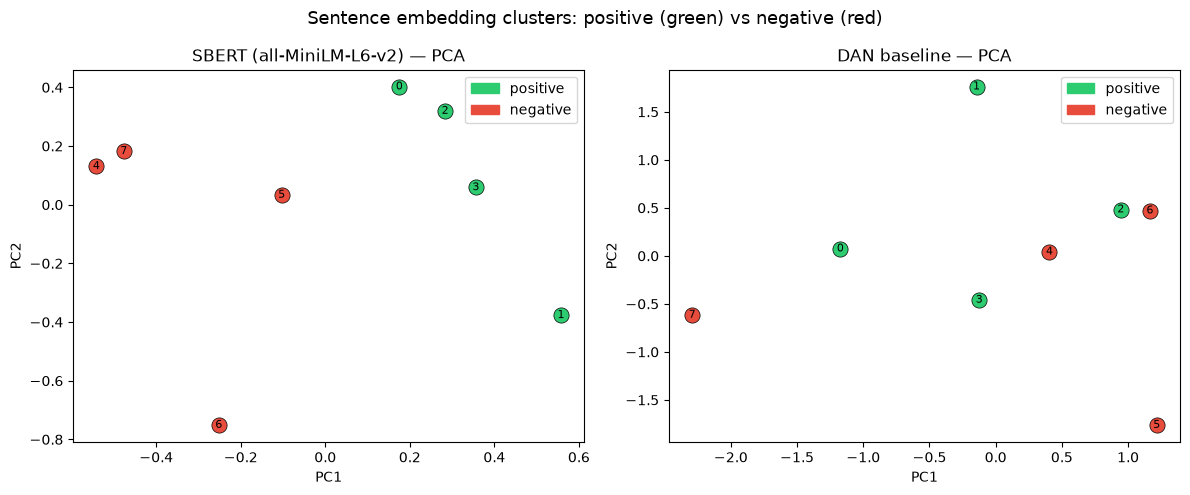

In [36]:
# Day 5: Visualise embedding clusters with 2D PCA
# Projects SBERT and DAN embeddings to 2D so we can see whether
# positive/negative IMDb reviews cluster separately.

from sklearn.decomposition import PCA

sample_texts = (
    ["A masterpiece of storytelling and visual style.",
     "One of the most moving films I have ever seen.",
     "Superb performances elevate an already brilliant script.",
     "A touching and unforgettable cinematic experience."]
    +
    ["A dull, overlong slog with no redeeming qualities.",
     "Terrible acting and a pointless, incoherent plot.",
     "I walked out halfway through — shockingly bad.",
     "A waste of talent and a waste of my evening."]
)
sample_labels = ["positive"] * 4 + ["negative"] * 4
color_map = {"positive": "#2ecc71", "negative": "#e74c3c"}

# SBERT
sbert_embs_vis = sbert_model.encode(sample_texts, convert_to_tensor=True, device=str(device)).cpu().numpy()
# DAN
dan_embs_vis = dan_encode(sample_texts).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, embs, title in [
    (axes[0], sbert_embs_vis, "SBERT (all-MiniLM-L6-v2) — PCA"),
    (axes[1], dan_embs_vis, "DAN baseline — PCA"),
]:
    pca = PCA(n_components=2)
    xy = pca.fit_transform(embs)
    for i, (label, txt) in enumerate(zip(sample_labels, sample_texts)):
        ax.scatter(xy[i, 0], xy[i, 1], c=color_map[label], s=120, edgecolors="k", linewidths=0.5)
        ax.annotate(f"{i}", (xy[i, 0], xy[i, 1]), fontsize=8, ha="center", va="center")
    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color=c, label=l) for l, c in color_map.items()])

plt.suptitle("Sentence embedding clusters: positive (green) vs negative (red)", fontsize=13)
plt.tight_layout()
plt.show()

### Week 7 Summary

| Component | Week 6 | Week 7 |
|---|---|---|
| Architecture | Single `TransformerBlock` | Stacked encoder (`TinyBert`) |
| Pre-training | None (trained from scratch on IMDb) | BERT-base (110M params, 3.3B word corpus) |
| Positional encoding | Sinusoidal or RoPE (from `utils.py`) | Learned absolute positions |
| Classification head | Mean pool → linear (`utils.py`) | `[CLS]` → linear (BERT fine-tuning) |
| Sentence embeddings | DAN mean pool (`masked_mean_pool`) | SBERT (Siamese BERT + mean pool) |
| Similarity task | Not covered | Semantic search + STS evaluation |

All of the utils from Week 6 (`TransformerBlock`, `MultiHeadAttention`, `masked_mean_pool`, `bpe_batch_encode`, `train_binary_classifier`, `plot_attention_heads`) were reused directly in Week 7 — either as comparison baselines or as the underlying building blocks that BERT and SBERT extend.

Week 8 continues to the generative side: decoder-only GPT-style models and encoder-decoder T5-style models.